## Imports & Configuration
### Boston Housing Dataset with focus on Median Value of Lower Socioecomonic Status Homes using Confidence & Prediction Intervals

In [3]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [4]:
import statsmodels.api as sm

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [6]:
dir()

['In',
 'NamespaceMagics',
 'Out',
 'VIF',
 '_',
 '_1',
 '_2',
 '__',
 '__K',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__import__',
 '__ipywidgets',
 '__loader__',
 '__name__',
 '__np',
 '__package__',
 '__pandas',
 '__pd',
 '__pyspark',
 '__session__',
 '__spec__',
 '__tf',
 '__torch',
 '__xr',
 '_attempt_import',
 '_check_imported',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_ih',
 '_ii',
 '_iii',
 '_jupyterlab_variableinspector_Jupyter',
 '_jupyterlab_variableinspector_default',
 '_jupyterlab_variableinspector_deletevariable',
 '_jupyterlab_variableinspector_dict_list',
 '_jupyterlab_variableinspector_displaywidget',
 '_jupyterlab_variableinspector_getcontentof',
 '_jupyterlab_variableinspector_getmatrixcontent',
 '_jupyterlab_variableinspector_getshapeof',
 '_jupyterlab_variableinspector_getsizeof',
 '_jupyterlab_variableinspector_is_matrix',
 '_jupyterlab_variableinspector_is_widget',
 '_jupyterlab_variableinspector_nms',
 '_oh',
 'anova_lm',
 '

In [7]:
import sys
!{sys.executable} -m pip install ISLP
!{sys.executable} -m pip show ISLP

Name: ISLP
Version: 0.4.1
Summary: Library for ISLP labs
Home-page: https://github.com/intro-stat-learning/ISLP
Author: 
Author-email: Trevor Hastie <hastie@stanford.edu>, Gareth James <gareth@emory.edu>, Jonathan Taylor <jonathan.taylor@stanford.edu>, Rob Tibshirani <tibs@stanford.edu>, Daniela Witten <dwitten@uw.edu>
License: Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    (1) Redistributions of source code must retain the above copyright
    notice, this list of conditions and the following disclaimer. 

    (2) Redistributions in binary form must reproduce the above copyright
    notice, this list of conditions and the following disclaimer in
    the documentation and/or other materials provided with the
    distribution.  

    (3)The name of the author may not be used to
    endorse or promote products derived from this software without
    specific prior written permission.

THIS 

In [8]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [9]:
A = np.array([3, 5, 11])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_prepare__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '

In [10]:
A.sum()

19

### Boston Housing Data

In [12]:
boston = load_data('Boston')
boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [13]:
X = pd.DataFrame({'intercept': np.ones(boston.shape[0]),
                  'lstat': boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [14]:
y = boston['medv']
model = sm.OLS(y, X)
results = model.fit()

In [15]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [16]:
design = MS(['lstat'])
design = design.fit(boston)
X = design.transform(boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


 - Using .fit_transform() to combine the actions in cell 32

In [18]:
design = MS(['lstat'])
X = design.fit_transform(boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [19]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        02:25:20   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

### Produce Confidence & Prediction Intervals for median home values with low socioeconomic status

In [22]:
import statsmodels.formula.api as smf

# df = your training dataframe, with columns: 'medv' (target) and 'lstat' (predictor)
fit = smf.ols("medv ~ lstat", data=boston).fit()

new_df = pd.DataFrame({"lstat": [5, 10, 15]})

pred = fit.get_prediction(new_df).summary_frame(alpha=0.05)
pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,29.803594,0.405247,29.007412,30.599776,17.565675,42.041513
1,25.053347,0.294814,24.474132,25.632563,12.827626,37.279068
2,20.303101,0.290893,19.731588,20.874613,8.077742,32.528459


#### Example Prediction Interval shows wider gap from including irreducible error
 - obs_ci_lower = 17.57:
 - if randomly picking 1 neighborhood with `lstat` = 5, then are 95% confident `medv` > 17.57

#### Confidence Interval answers what the average value at specified lstat
 - does not include irreducible error

#### Recap: Average predicted home value lstat=5 is ~ 29.8 but could spread due to real-world variation

In [24]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] +b]
    ax.plot(xlim, ylim, *args, **kwargs)

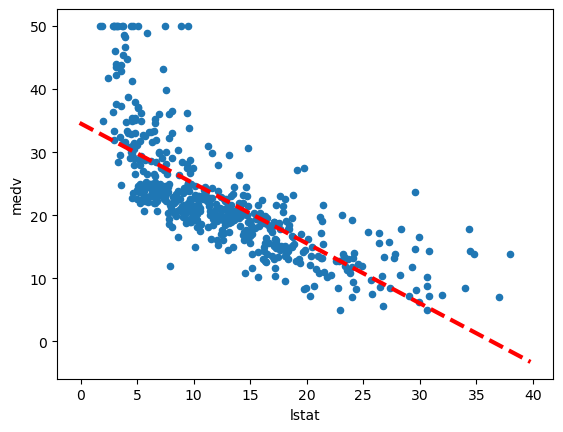

In [25]:
ax = boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params.iloc[0],
       results.params.iloc[1],
       'r--',
       linewidth=3)

#### Expected observation of median value of homes decreasing with increased lower socioeconomic status

(<Figure size 640x480 with 1 Axes>, <Axes: >)

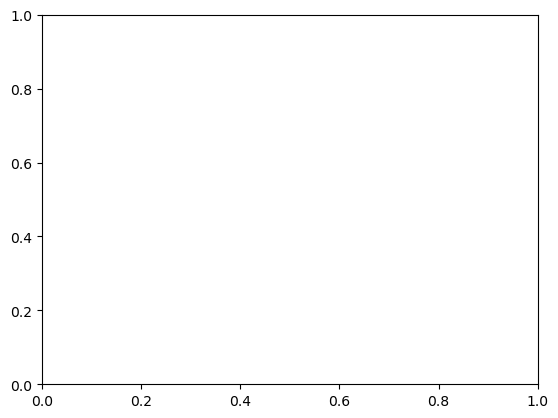

In [73]:
subplots()
#returns tuple [0] is figure object and [1] is the axes object

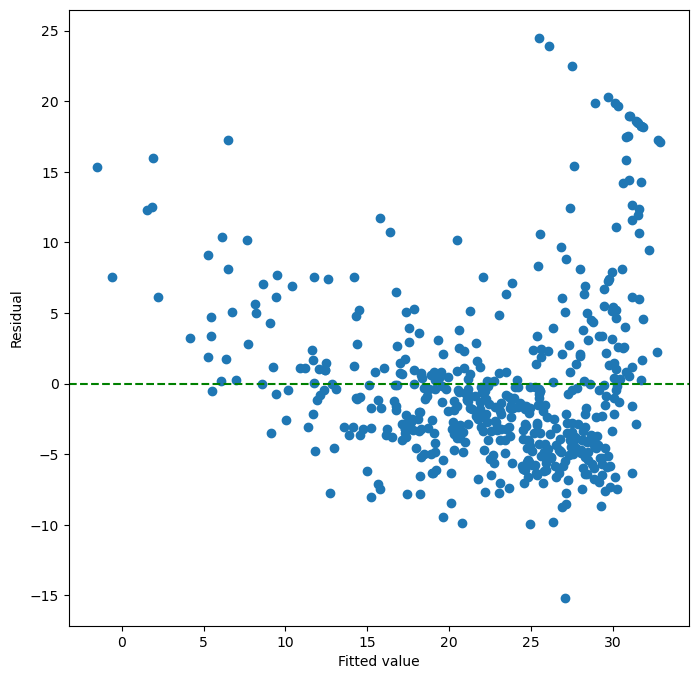

In [51]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='g', ls='--');

 - The residuals are mostly negative when fitted values are high showing the model is overpredicting in that region

In [64]:
boston.shape

(506, 13)

In [66]:
X.shape
#506 records with 2 predictors lstat, medv

(506, 2)

374

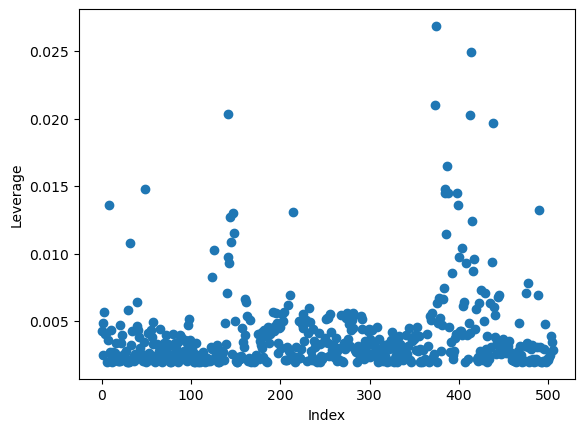

In [58]:
infl = results.get_influence()
ax = subplots()[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

 - $SE_{mean}$ = $x_{0}^{T}$($X^{T}X$)$^{-1}$$x_{0}$ uses matrix geometry to measure uncertainty of a prediction
 - Standard Error of the predicted mean at a specific point and leverage are directly related
 - Leverage controls width of both confidence and prediction intervals
 - High leverage has high interval widths
 - np.argmax(infl.hat_matrix_diag) = 374 is the highest leverage point
 - Leverage measures how far predictor X is from the mean of X

In [84]:
boston.loc[374, 'lstat']

37.97

In [86]:
boston['lstat'].mean()

12.653063241106722

In [88]:
results.resid[374]

15.319533082807775

In [90]:
infl = results.get_influence()
cooks = infl.cooks_distance[0]
cooks[374]

0.0861620514077547

 - point 374 is quite far from the mean predictor space indicating its influential
 - Cook's distance of 0.086 is greater than 4/n = 4/506 = 0.0079 indicating its influential
 - High leverage + large residual = influential

In [93]:
fit2 = smf.ols("medv ~ lstat + I(lstat**2)", data=boston).fit()
infl2 = fit2.get_influence()
cooks2 = infl2.cooks_distance[0]
cooks2[374]

0.016308067718722955

 - changing the model from linear to quadratic shows the relationship is not perfectly linear between medv and lstat
 - the quadratic term allows the model to curve downward at the higher lstat 